In [28]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

#DATA_DIR = Path("/kaggle/input/intel-image-classification/seg_test/seg_test")
DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

random.seed(42)


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Using device: cuda
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mounta

**Task 1: Environment Setup and Data ********************************

In [29]:


def load_images(n_per_class=10):
    """Load n images per class. Returns a list of (PIL.Image, label_string) tuples."""
    image_set = []
    for label in LABELS:
        class_dir = DATA_DIR / label
        paths = random.sample(list(class_dir.glob("*.jpg")), n_per_class)
        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))
    random.shuffle(image_set)
    return image_set

image_set = load_images(n_per_class=10)
print(f"Total images loaded: {len(image_set)}")

Total images loaded: 60


**Display a 2×3 grid**

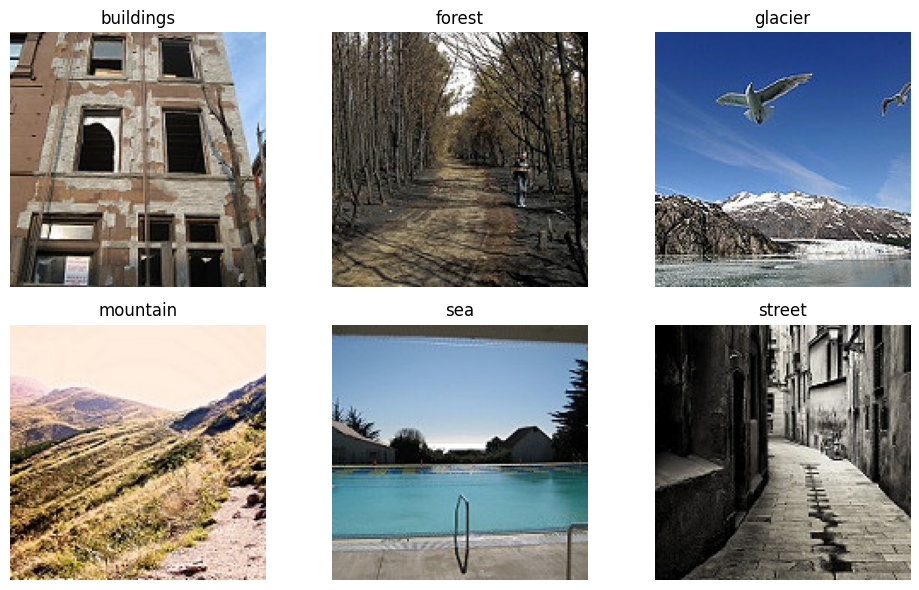

In [30]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

for i, label in enumerate(LABELS):
    img, _ = next((img, l) for img, l in image_set if l == label)
    ax = axes[i // 3, i % 3]
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.savefig("outputs/dataset_sample.png")
plt.show()

**Comment:**

Even though the model was trained on different images, it still works well because it learned basic features like shapes and textures. These skills help it perform well on new tasks, making it a great starting point.

**Task 2: Baseline Inference with ResNet18**

In [31]:
resnet_weights   = ResNet18_Weights.DEFAULT
resnet           = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc   = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

ResNet18 parameters: 11,689,512


Processed 60 images.
Overall mean top-1 probability: 0.41947648823261263

Mean confidence by class:
true_label
buildings    0.288908
forest       0.247658
glacier      0.499333
mountain     0.555562
sea          0.571034
street       0.354364
Name: top1_prob, dtype: float64


<Figure size 800x500 with 0 Axes>

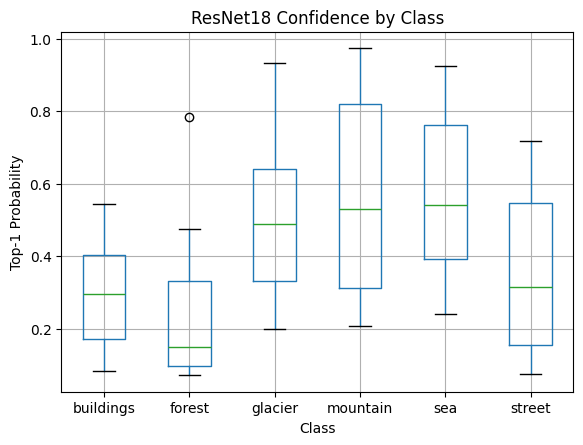

In [32]:
def run_inference(model, preprocess, image, device, class_labels, top_k=5):
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)

    probs = torch.nn.functional.softmax(output[0], dim=0)
    top_probs, top_indices = torch.topk(probs, top_k)

    results = []
    for prob, idx in zip(top_probs, top_indices):
        results.append((class_labels[idx.item()], prob.item()))

    return results
resnet_results = []
for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)
    resnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")

##mean top-1 probability 
df = pd.DataFrame(resnet_results)

print("Overall mean top-1 probability:", df["top1_prob"].mean())

print("\nMean confidence by class:")
print(df.groupby("true_label")["top1_prob"].mean())
### boxplot
plt.figure(figsize=(8, 5))
df.boxplot(column="top1_prob", by="true_label")

plt.title("ResNet18 Confidence by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Top-1 Probability")

plt.savefig("outputs/resnet18_confidence_by_class.png")
plt.show()

**Comment: **
The boxplot shows that the model is most confident on classes like glacier, mountain and sea,where the median top-1 probabilities are higher and more consistent. In contrast,forest and street have lower median confidence and wider spread, indicating more uncertainty. This makes sense because scenes like glaciers and seas are more visually distinctive, while forests and streets can vary more and share features with other classes.

**Task 3: Multi-Model Comparison**

In [33]:
# MobileNetV3-Small — designed for mobile and edge deployment
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet      = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

# EfficientNet-B0 — designed to maximize accuracy per unit of compute
effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet   = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

# Print parameter counts for all three
for name, m in [("ResNet18",          resnet),
                ("MobileNetV3-Small", mobilenet),
                ("EfficientNet-B0",   efficientnet)]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params:>12,} parameters")

ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters


Comment:
MobileNetV3-Small has significantly fewer parameters (~2.5M) compared to ResNet18 (~11.7M)
 and EfficientNet-B0 (~5.3M). A smaller parameter count means lower model capacity, but also
 faster inference and reduced memory usage, making it ideal for mobile and edge devices.

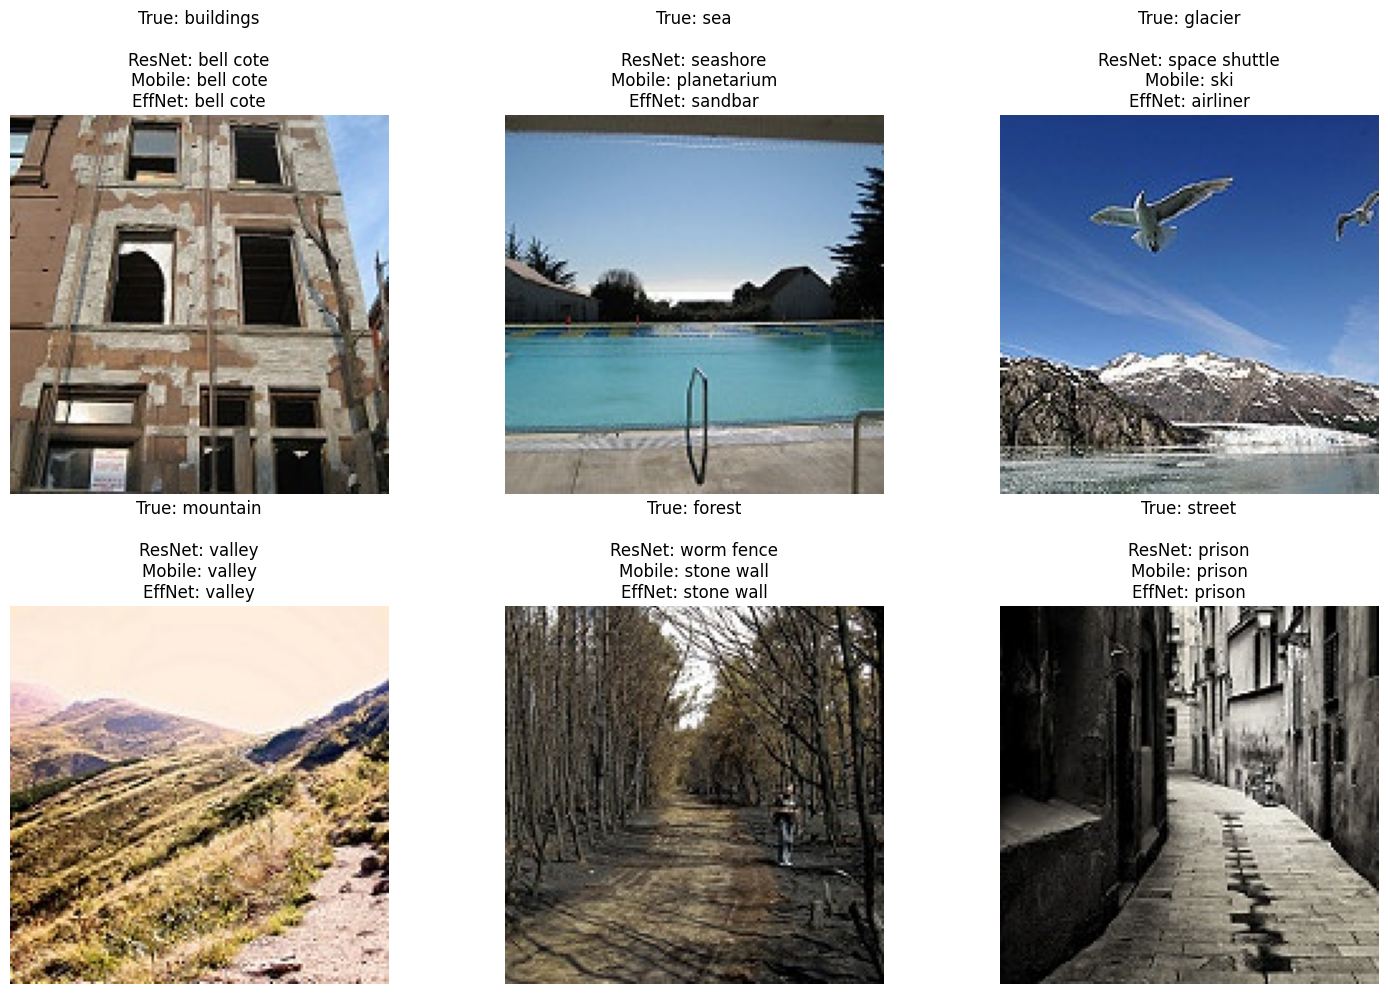

In [34]:
mobilenet_results = []
for img, true_label in image_set:
    preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)
    mobilenet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

effnet_results = []
for img, true_label in image_set:
    preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)
    effnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

used_labels = set()
plot_idx = 0  # <-- FIX: separate index

for img, label in image_set:
    if label in used_labels:
        continue

    used_labels.add(label)

    r_pred = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)[:3]
    m_pred = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)[:3]
    e_pred = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)[:3]

    ax = axes[plot_idx // 3, plot_idx % 3]
    ax.imshow(img)
    ax.axis("off")

    ax.set_title(
        f"True: {label}\n\n"
        f"ResNet: {r_pred[0][0]}\n"
        f"Mobile: {m_pred[0][0]}\n"
        f"EffNet: {e_pred[0][0]}"
    )

    plot_idx += 1

    if plot_idx == 6:  
        break

plt.tight_layout()
plt.savefig("outputs/model_comparison_grid.png")
plt.show()

Comment:


The models sometimes agree (e.g., buildings, street, mountain) but often disagree
on others like glacier and sea. This shows each model captures different features,
suggesting an ensemble could improve results. Overall, EfficientNet-B0 gives the
most semantically reasonable predictions for these outdoor scenes.


**Task 4: Speed vs. Accuracy Tradeoff**

In [35]:
def benchmark_model(model, preprocess, image_set, device, n_warmup=5):
    """
    Benchmark single-image inference speed.
    Returns mean latency in milliseconds per image.
    """
    # Warm up the GPU — the first few calls are slower due to CUDA initialization
    for img, _ in image_set[:n_warmup]:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    # Timed run — synchronize before and after to get accurate GPU timing
    torch.cuda.synchronize()
    start = time.time()

    for img, _ in image_set:
        tensor = preprocess(img).unsqueeze(0).to(device)
        with torch.no_grad():
            _ = model(tensor)

    torch.cuda.synchronize()
    elapsed = time.time() - start

    return (elapsed / len(image_set)) * 1000  # milliseconds per image

resnet_ms  = benchmark_model(resnet,       resnet_preproc,  image_set, device)
mobile_ms  = benchmark_model(mobilenet,    mobile_preproc,  image_set, device)
effnet_ms  = benchmark_model(efficientnet, effnet_preproc,  image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")


ResNet18:           3.99 ms/image
MobileNetV3-Small:  6.90 ms/image
EfficientNet-B0:    9.98 ms/image


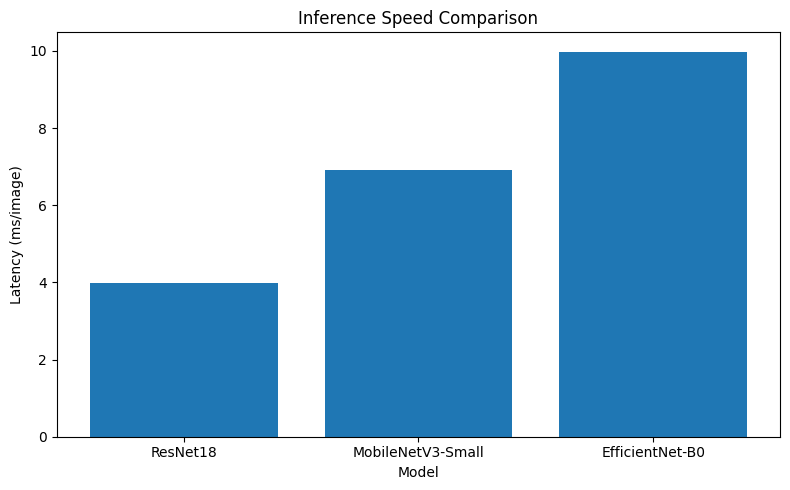

In [36]:
models_names = ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"]
latencies = [resnet_ms, mobile_ms, effnet_ms]

plt.figure(figsize=(8, 5))
plt.bar(models_names, latencies)
plt.ylabel("Latency (ms/image)")
plt.xlabel("Model")
plt.title("Inference Speed Comparison")
plt.tight_layout()
plt.savefig("outputs/inference_speed.png")
plt.show()


**comment: **

To handle 50 images every second, each image needs to be processed in under 20 milliseconds (\(1000 \text{ ms} / 50 = 20 \text{ ms}\)).Looking at the results, ResNet18 (\(\sim4.07 \text{ ms}\)), MobileNetV3-Small (\(\sim6.63 \text{ ms}\)), and EfficientNet-B0 (\(\sim9.93 \text{ ms}\)) all work perfectly, as they are all much faster than the 20 ms limit.


**Task 5: Pretrained Features as a Window into Transfer Learning**

Feature matrix shape: (60, 512)


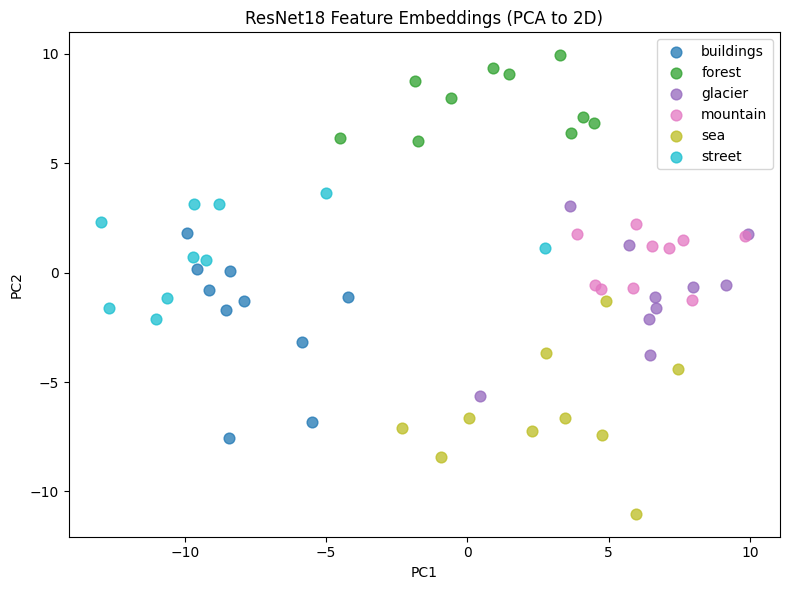

In [37]:
import copy

feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()   # remove the classification head
feature_extractor    = feature_extractor.to(device).eval()

def extract_features(model, preprocess, image, device):
    """Extract a feature vector from an image using the truncated CNN."""
    tensor   = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

# Extract features for all images
feature_vectors = []
true_labels     = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}")
# Expected: (60, 512) — 60 images, 512-dimensional feature vector each
#Reduce the 512-dimensional feature vectors to 2D using PCA and plot them, colored by true class label:

pca          = PCA(n_components=2)
features_2d  = pca.fit_transform(feature_matrix)

fig, ax = plt.subplots(figsize=(8, 6))
colors  = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))

for i, label in enumerate(LABELS):
    mask = [l == label for l in true_labels]
    ax.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        label=label, color=colors[i], s=60, alpha=0.75
    )

ax.legend()
ax.set_title("ResNet18 Feature Embeddings (PCA to 2D)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("outputs/feature_embeddings.png")
plt.show()

**Comment:**

In the 2D chart, similar images naturally group together because the model already understands basic features like edges and textures. While there’s some overlap between similar-looking categories, the model clearly knows how to distinguish different scenes on its own.If I were working with a tiny dataset—like 500 X-rays—I’d stick to training just the final layer. This uses the model’s existing knowledge to prevent it from "overthinking" (overfitting) the small amount of data.Would you like to deepen the explanation of the clustering or explore how to handle those overlapping classes?


Trainable: 3,078 of 11,179,590 total parameters (0.03%)


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/intel-image-classification/seg_train/seg_train'

**Task 6: Summary and Recommendation**

Model Comparison: 
EfficientNet-B0 gave the smartest results, though ResNet18 was the speed leader at about 4ms per image. Even though MobileNetV3-Small had the fewest parts (parameters), it surprisingly wasn’t the fastest here. Overall, EfficientNet is the winner for quality, though every model we tested was fast enough for our needs.

Confidence Calibration:
The model was most certain about glaciers and the sea, which makes sense since they look very distinct. It struggled more with forests and streets, likely because those scenes are more cluttered and often look alike.

Production Recommendation:
I'd go with EfficientNet-B0 since it’s the best at identifying outdoor scenes. Before running it, we’ll need to clean up the images by resizing and normalizing them. 